<a href="https://colab.research.google.com/github/adamjtnrqlby/UTS_VisiKomputer/blob/main/UTS_VisiKomputer_23423053.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import pytesseract
import re

In [82]:
uploaded = files.upload()

Saving plat.jpg to plat (9).jpg


In [83]:
img = cv2.imread('plat.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

array([[[111, 111, 113],
        [111, 111, 113],
        [111, 111, 113],
        ...,
        [142, 143, 147],
        [141, 142, 146],
        [141, 142, 146]],

       [[111, 111, 113],
        [111, 111, 113],
        [111, 111, 113],
        ...,
        [141, 142, 146],
        [141, 142, 146],
        [141, 142, 146]],

       [[112, 112, 114],
        [112, 112, 114],
        [112, 112, 114],
        ...,
        [140, 141, 145],
        [141, 142, 146],
        [141, 142, 146]],

       ...,

       [[111, 110, 115],
        [111, 110, 115],
        [110, 109, 114],
        ...,
        [125, 125, 127],
        [125, 125, 127],
        [126, 126, 128]],

       [[149, 148, 153],
        [149, 148, 153],
        [148, 147, 152],
        ...,
        [162, 162, 162],
        [162, 162, 162],
        [163, 163, 163]],

       [[178, 179, 181],
        [178, 179, 181],
        [179, 180, 182],
        ...,
        [191, 192, 194],
        [192, 193, 195],
        [192, 193, 195]]], dtype=uint8)
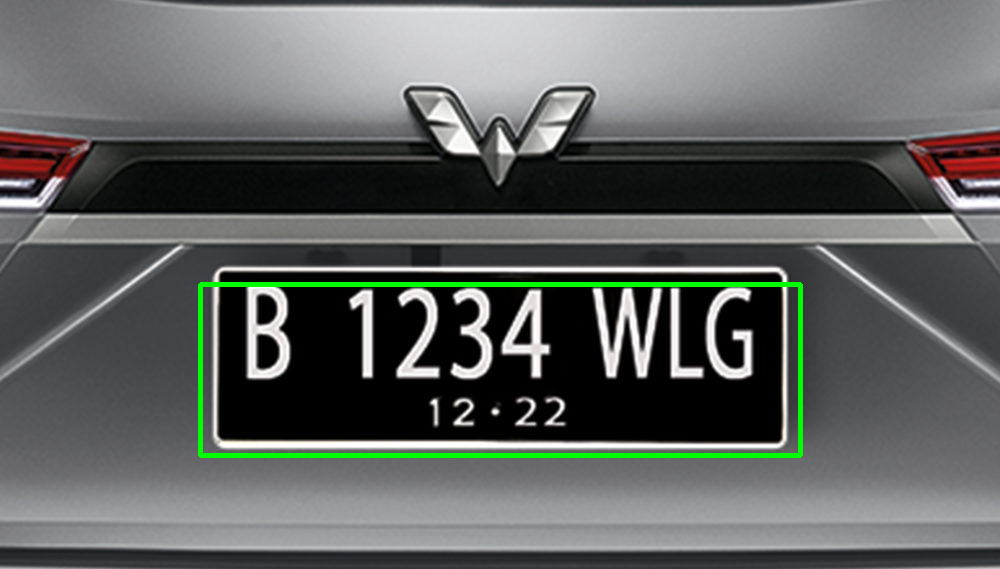

In [84]:
h, w, _ = img.shape

x1, y1 = int(w*0.2), int(h*0.5)
x2, y2 = int(w*0.8), int(h*0.8)

crop = img[y1:y2, x1:x2]

# gambar kotak di gambar asli
img_box = img_rgb.copy()
cv2.rectangle(img_box, (x1,y1), (x2,y2), (0,255,0), 3)

In [85]:
gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

# buang bagian bawah
h2, w2 = gray.shape
gray = gray[0:int(h2*0.7), :]

gray = cv2.resize(gray, None, fx=3, fy=3)
gray = cv2.GaussianBlur(gray, (3,3), 0)

_, thresh = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

In [86]:
text = pytesseract.image_to_string(
    thresh,
    config='--psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
)

text = text.strip()
text = re.sub(r'[^A-Z0-9]', '', text)

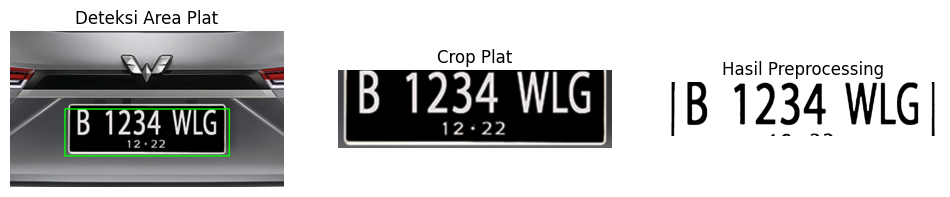

✅ HASIL DETEKSI PLAT: 1B1234WLG


In [87]:
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(img_box)
plt.title("Deteksi Area Plat")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
plt.title("Crop Plat")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(thresh, cmap='gray')
plt.title("Hasil Preprocessing")
plt.axis('off')

plt.show()

print("✅ HASIL DETEKSI PLAT:", text)